In [33]:
%load_ext autoreload
%autoreload 2

import networkx as nx
from agents import PopulationManager, useful_graph_metrics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# 2. a circulant graph with 20 vertices where each vertex is attached to four neighbors on either side
graph_2_circulant = nx.circulant_graph(20,[1,2])

# 3. a complete graph with 100 vertices (nx.complete graph(100))
graph_3_complete = nx.complete_graph(100) 

# 4. a 10 × 10 lattice with 100 vertices (nx.grid 2d graph(10,10))
graph_4_lattice = nx.convert_node_labels_to_integers(nx.grid_2d_graph(10,10))

# 5. a scale-free network with 100 vertices (nx.barabasi albert graph(100,???)
graph_5_barabasi_100 = nx.convert_node_labels_to_integers(nx.barabasi_albert_graph(100, 5))
                                   
# 6. a scale-free network with 410 vertices (nx.barabasi albert graph(410,???)
graph_6_barabasi_410 = nx.convert_node_labels_to_integers(nx.barabasi_albert_graph(410, 10))


In [5]:
# 7. infect-dublin network, which has 410 vertices; described and downloadable here:
from read_dublin_graph import _read_graph_from_file
graph_7_dublin = _read_graph_from_file('ia-infect-dublin.mtx')
graph_7_dublin = nx.convert_node_labels_to_integers(graph_7_dublin)

In [45]:
all_graphs = [graph_3_complete,graph_4_lattice, graph_5_barabasi_100, graph_6_barabasi_410,graph_7_dublin]
all_graphs_names = ["Complete Graph", "Lattice Graph", "Barabasi Size 100", "Barabasi Size 410", "Dublin Graph"]

In [6]:

# Graph 1
G = nx.circulant_graph(20,[1,2,3,4])

num_steps = 200
manager = PopulationManager(graph=G)
for step in range(num_steps):
    manager.step_all_agents()


In [7]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display


def plot_graph_step(G, manager, step, pos=None, with_labels=True, node_size=300):
    """
    Plot the graph at a specific step.
    """

    if pos is None:
        pos = nx.spring_layout(G)

    node_order = list(G.nodes())
    colors = manager.get_color_map(step)

    fig, ax = plt.subplots()

    nx.draw_networkx_edges(G, pos, ax=ax)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=node_order,
        node_color=colors,
        node_size=node_size,
        ax=ax
    )

    if with_labels:
        nx.draw_networkx_labels(G, pos, ax=ax)

    ax.set_axis_off()

    display(fig)      # ensures it shows in any cell
    plt.close(fig)    # prevents duplicate rendering

In [8]:
%matplotlib notebook

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import networkx as nx
import time


def animate_graph_history(
    G,
    manager,
    delay=0.1,
    pos=None,
    with_labels=True,
    node_size=300,
):
    """
    Animate node color changes over the manager history.

    Parameters
    ----------
    G : networkx.Graph
        The graph to draw.
    manager : object
        Must provide:
            - get_color_map(i)
            - get_history()
    delay : float, optional
        Pause time between frames.
    pos : dict, optional
        Node positions. If None, uses nx.spring_layout(G).
    with_labels : bool, optional
        Whether to draw node labels.
    node_size : int, optional
        Size of nodes.
    """
    if pos is None:
        pos = nx.spring_layout(G)

    node_order = list(G.nodes())
    history = manager.get_history()

    fig, ax = plt.subplots()
    prev_colors = manager.get_color_map(0)

    for i in range(len(history)):
        ax.clear()

        # Always draw edges
        nx.draw_networkx_edges(G, pos, ax=ax)

        # Optionally draw labels
        if with_labels:
            nx.draw_networkx_labels(G, pos, ax=ax)

        curr_colors = manager.get_color_map(i)

        if i == 0:
            changed_nodes = node_order
            changed_colors = curr_colors
            unchanged_nodes = []
            unchanged_colors = []
        else:
            changed_nodes = [
                node_order[j]
                for j in range(len(node_order))
                if curr_colors[j] != prev_colors[j]
            ]
            changed_colors = [
                curr_colors[j]
                for j in range(len(node_order))
                if curr_colors[j] != prev_colors[j]
            ]

            unchanged_nodes = [
                node_order[j]
                for j in range(len(node_order))
                if curr_colors[j] == prev_colors[j]
            ]
            unchanged_colors = [
                curr_colors[j]
                for j in range(len(node_order))
                if curr_colors[j] == prev_colors[j]
            ]

        # Draw unchanged nodes first
        if unchanged_nodes:
            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=unchanged_nodes,
                node_color=unchanged_colors,
                node_size=node_size,
                ax=ax,
            )

        # Draw changed nodes on top
        if changed_nodes:
            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=changed_nodes,
                node_color=changed_colors,
                node_size=node_size,
                ax=ax,
            )

        ax.set_axis_off()
        display(fig)
        clear_output(wait=True)
        time.sleep(delay)

        prev_colors = curr_colors.copy()

    plt.close(fig)

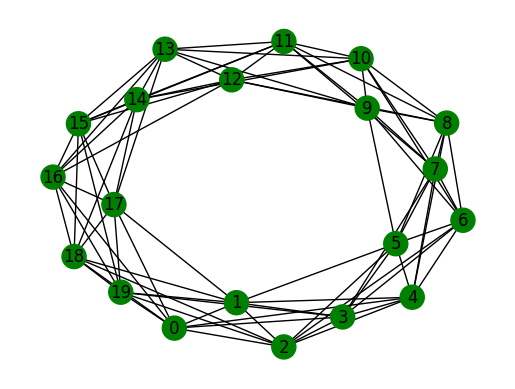

In [9]:
animate_graph_history(G, manager)

<IPython.core.display.Javascript object>

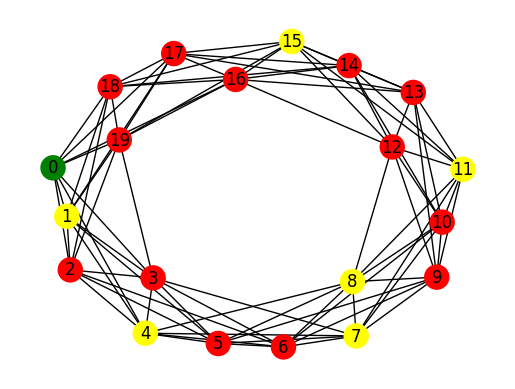

In [13]:
plot_graph_step(G, manager, 10)

In [14]:

# Graph 4
num_steps = 200
manager_4 = PopulationManager(graph=graph_2_circulant)
for step in range(num_steps):
    manager_4.step_all_agents()


<IPython.core.display.Javascript object>

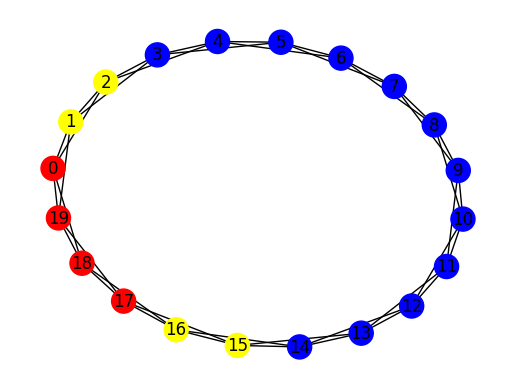

In [15]:
plot_graph_step(graph_2_circulant, manager_4, 5)

In [18]:
def run_sims(graph, iterations, steps_per_sim=150):
    
    histories = []
    
    for _ in range(iterations):
        manager = PopulationManager(graph=graph)
        for step in range(steps_per_sim):
            manager.step_all_agents()

        histories.append(manager.get_history_as_counts())
    
    return histories, manager


In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_seir_iqr(data):
    """
    data format:
        data[simulation][state][time]
        state order = [S, E, I, R]
    """

    data = np.array(data)

    # shape becomes (runs, 4, time)
    q25 = np.percentile(data, 25, axis=0)
    median = np.percentile(data, 50, axis=0)
    q75 = np.percentile(data, 75, axis=0)

    time = np.arange(data.shape[2])

    labels = ["Susceptible", "Exposed", "Infected", "Recovered"]
    colors = ["blue", "yellow", "red", "green"]

    fig, ax = plt.subplots()

    for (i, label), color in zip(enumerate(labels), colors):
        ax.plot(time, median[i], label=label, color=color)
        ax.fill_between(time, q25[i], q75[i], alpha=0.25, color=color)

    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.legend()

    plt.show()

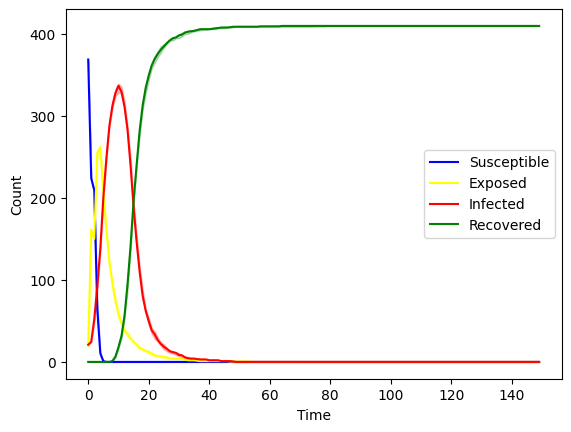

In [39]:
%matplotlib notebook
%matplotlib inline

data, manager = run_sims(graph_6_barabasi_410, 10, steps_per_sim=150)

plot_seir_iqr(data)


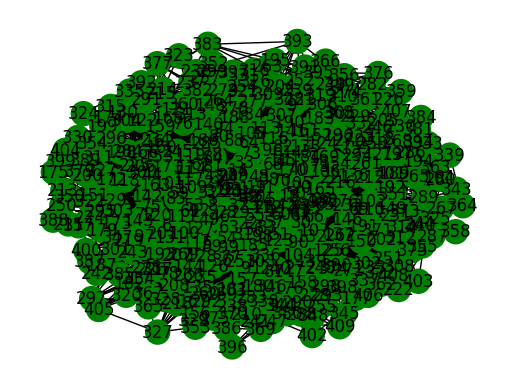

In [40]:
animate_graph_history(graph_6_barabasi_410, manager)

In [41]:
results = manager.get_useful_metrics() | useful_graph_metrics(graph_6_barabasi_410)
results

{'time to peak infection': 10,
 'peak infections': 327,
 'time when steady state reached': 45,
 'number of uninfected individuals at the end of the experiment': 0,
 'the maximum degree': 92,
 'the average degree': 19.51219512195122,
 'diameter of the graph': 3,
 'radius of the graph': 2,
 'density': 0.047707078537778044}

In [49]:

graph_stats = { name: useful_graph_metrics(g)
    for name, g in zip(all_graphs_names, all_graphs)
}

import pandas as pd

df = pd.DataFrame.from_dict(graph_stats, orient="index")
print(df)

                   maximum degree  average degree  diameter  radius   density
Complete Graph                 99       99.000000         1       1  1.000000
Lattice Graph                   4        3.600000        18      10  0.036364
Barabasi Size 100              33        9.500000         4       3  0.095960
Barabasi Size 410              92       19.512195         3       2  0.047707
Dublin Graph                   50       13.487805         9       5  0.032978


In [ ]:

results = manager.get_useful_metrics() | useful_graph_metrics(G)
    results


{'time to peak infection': 20,
 'peak infections': 27,
 'time when steady state reached': 72,
 'number of uninfected individuals at the end of the experiment': 0,
 'the maximum degree': 8,
 'the average degree': 8.0,
 'diameter of the graph': 3,
 'radius of the graph': 3,
 'density': 0.42105263157894735}

Three useful summary variables are 
- time-to-peak infection, 
- peak infections, 
- time until no new infections, 
- number of uninfected individuals at the end of the experiment. 

The time to reach steady state is the number of days until there are no more agents in the infectious or exposed states.

The number of uninfected individuals will be the average number of agents in the susceptible state at the end of the simulation.